# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
# Cargar la imagen como un array de NumPy
image = plt.imread('data/ejer_kmeans.png')
# Forma de la imagen
image.shape
# 764 de alto (filas), 1499 de ancho (columnas) y 3 canales de color (RGB)

(764, 1499, 3)

In [3]:
# Número total de pixeles (dividir entre los 3 canales de color)
image.size/3

1145236.0

In [4]:
# Lo mismo pero alto x ancho
764*1499

1145236

In [5]:
# array de numpy
image

array([[[0.5686275 , 0.5803922 , 0.61960787],
        [0.5529412 , 0.5647059 , 0.6039216 ],
        [0.54901963, 0.5686275 , 0.6039216 ],
        ...,
        [0.7529412 , 0.7882353 , 0.827451  ],
        [0.74509805, 0.78039217, 0.8235294 ],
        [0.1254902 , 0.12941177, 0.14117648]],

       [[0.5647059 , 0.5764706 , 0.6156863 ],
        [0.54901963, 0.5647059 , 0.6       ],
        [0.54901963, 0.5686275 , 0.6039216 ],
        ...,
        [0.7529412 , 0.7882353 , 0.83137256],
        [0.7490196 , 0.78431374, 0.8235294 ],
        [0.1254902 , 0.12941177, 0.14117648]],

       [[0.5647059 , 0.5764706 , 0.6156863 ],
        [0.54901963, 0.5647059 , 0.6       ],
        [0.54901963, 0.5686275 , 0.6039216 ],
        ...,
        [0.7529412 , 0.7921569 , 0.8352941 ],
        [0.7529412 , 0.7921569 , 0.83137256],
        [0.1254902 , 0.12941177, 0.14117648]],

       ...,

       [[0.26666668, 0.28627452, 0.29411766],
        [0.26666668, 0.28627452, 0.29803923],
        [0.26666668, 0

Muestra la imagen para ver que se ha cargado bien

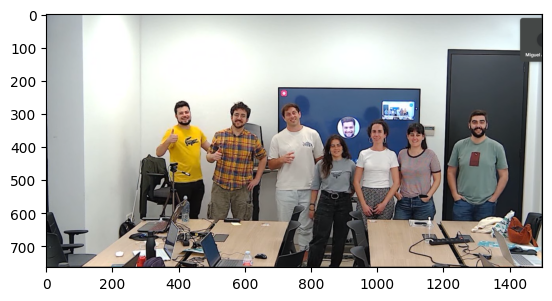

In [6]:
# comprobación de que la imagen se ha cargado bien:
plt.imshow(image)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [7]:
# Convertir de (alto, ancho, 3) a (alto*ancho, 3)
X = image.reshape(-1,3)
X.shape

(1145236, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [8]:
k = 10
kmeans = KMeans(n_clusters=k, n_init=10, random_state=10).fit(X)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [9]:
centers = kmeans.cluster_centers_
labels = kmeans.labels_

print(centers)
print(labels)

[[0.2377001  0.2367801  0.24836913]
 [0.8690728  0.8870832  0.8651217 ]
 [0.76094186 0.7658365  0.7520889 ]
 [0.09676272 0.09039944 0.098095  ]
 [0.5416983  0.5001065  0.47883594]
 [0.9681157  0.9839448  0.96868944]
 [0.4736287  0.33859813 0.27330172]
 [0.79658866 0.6124931  0.1008828 ]
 [0.26986778 0.3450061  0.45598835]
 [0.70746094 0.6684117  0.6264313 ]]
[4 4 4 ... 3 3 3]


#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [10]:
# Sustituir cada pixel por su centroide
segmented_pixels = centers[labels]

# Volver a la forma original
segmented_image = segmented_pixels.reshape(image.shape)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

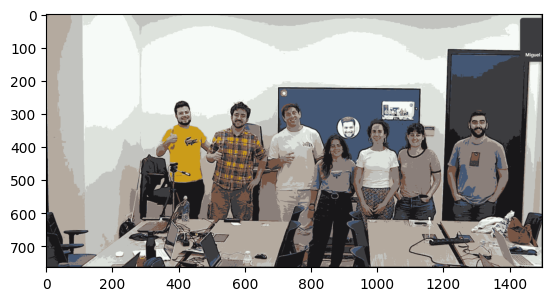

In [11]:
# Imprimir imagen:
fig = plt.figure()
plt.imshow(segmented_image)

In [12]:
# Guardar imagen:
fig.savefig("data/kmeans_1_output.png")

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [15]:
def colores_imagen(imagen, n_colores, save=False):
    imagen = plt.imread(imagen)
    X = imagen.reshape(-1,3)
    kmeans = KMeans(n_clusters=n_colores).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    fig = plt.figure(figsize=(15,15))
    plt.imshow(segmented_img.reshape(imagen.shape))

    if save:
        fig.savefig("imagen.png")

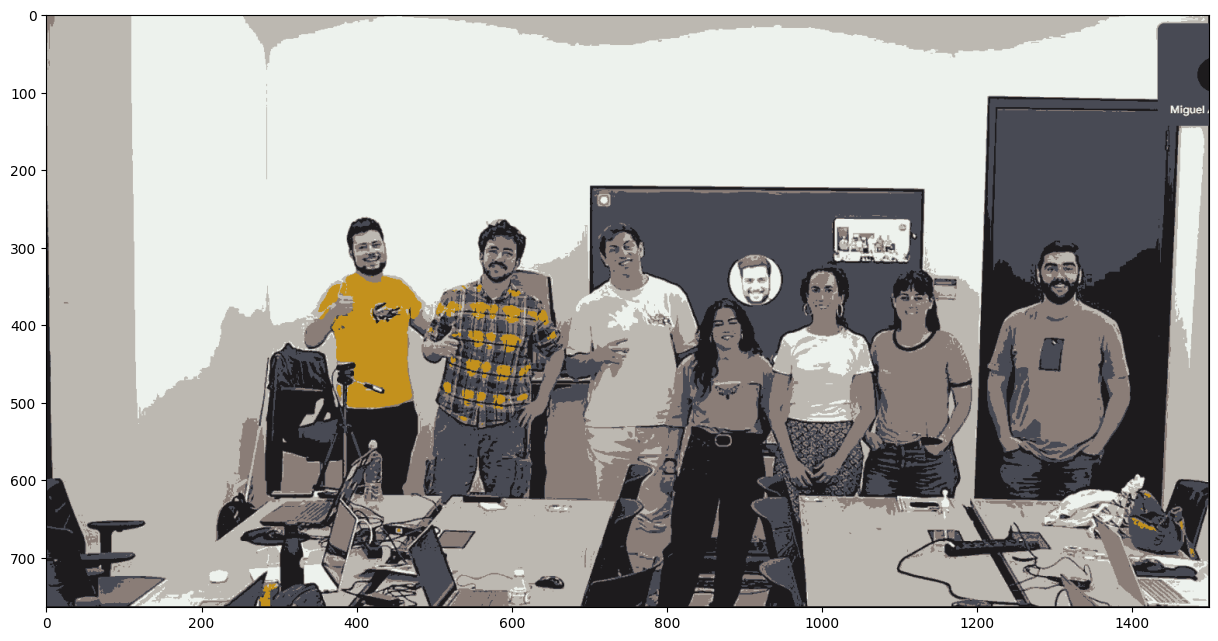

In [16]:
colores_imagen('data/ejer_kmeans.png', 6)